In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos
# La 'r' inicial evita errores con las barras invertidas de Windows
ruta_archivo = r'C:\Users\Fernando\Documents\proyecto\ipv_datos.csv'
df = pd.read_csv(ruta_archivo, sep=';')

# 2. Exploración inicial
print("Primeras 5 filas del dataset:")
print(df.head())

print("\nInformación general (tipos de datos y valores nulos):")
print(df.info())

Primeras 5 filas del dataset:
  Total Nacional Comunidades y Ciudades Autónomas  \
0       Nacional                              NaN   
1       Nacional                              NaN   
2       Nacional                              NaN   
3       Nacional                              NaN   
4       Nacional                              NaN   

  General, vivienda nueva y de segunda mano Índices y tasas Periodo    Total  
0                                   General          Índice  2025T4  186,750  
1                                   General          Índice  2025T3  183,389  
2                                   General          Índice  2025T2  178,184  
3                                   General          Índice  2025T1  171,296  
4                                   General          Índice  2024T4  165,433  

Información general (tipos de datos y valores nulos):
<class 'pandas.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 6 columns):
 #   Column              

Tamaño final de nuestra serie temporal: 76 trimestres.

Primeros 5 valores originales:
 [145.935 150.103 151.719 150.64  150.082]
Primeros 5 valores escalados:
 [0.55413908 0.5996701  0.6173232  0.60553626 0.59944069]


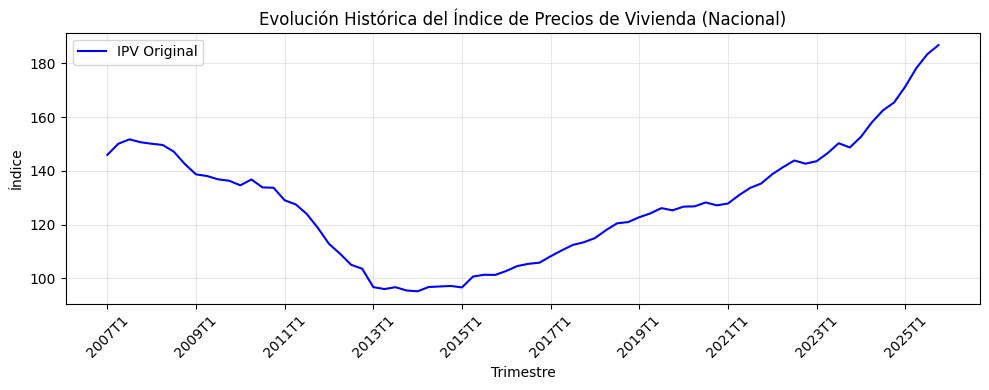

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Filtrar para quedarnos solo con el Índice General a nivel Nacional
df_nacional = df[
    (df['Total Nacional'] == 'Nacional') & 
    (df['Comunidades y Ciudades Autónomas'].isna()) & # Excluimos las CCAA
    (df['General, vivienda nueva y de segunda mano'] == 'General') &
    (df['Índices y tasas'] == 'Índice')
].copy()

# 2. Limpiar la columna 'Total' (cambiar coma por punto y convertir a número)
df_nacional['Total'] = df_nacional['Total'].astype(str).str.replace(',', '.')
df_nacional['Total'] = pd.to_numeric(df_nacional['Total'], errors='coerce')

# 3. Ordenar cronológicamente (pasado -> futuro)
df_nacional = df_nacional.sort_values(by='Periodo', ascending=True).reset_index(drop=True)

# 4. Tratar valores nulos (La interpolación es ideal para series temporales)
df_nacional['Total'] = df_nacional['Total'].interpolate()

# ---> FASE DE ESCALAMIENTO

# 5. Inicializar el MinMaxScaler (rango de 0 a 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# Extraer los valores como una matriz 2D
valores_ipv = df_nacional['Total'].values.reshape(-1, 1)

# Ajustar y transformar los datos
ipv_escalado = scaler.fit_transform(valores_ipv)

print("Tamaño final de nuestra serie temporal:", len(ipv_escalado), "trimestres.")
print("\nPrimeros 5 valores originales:\n", valores_ipv[:5].flatten())
print("Primeros 5 valores escalados:\n", ipv_escalado[:5].flatten())

# Graficamos para verificar que la curva tiene sentido histórico
plt.figure(figsize=(10, 4))
plt.plot(df_nacional['Periodo'], valores_ipv, label='IPV Original', color='blue')
plt.title('Evolución Histórica del Índice de Precios de Vivienda (Nacional)')
plt.xlabel('Trimestre')
plt.ylabel('Índice')
plt.xticks(np.arange(0, len(df_nacional), 8), rotation=45) # Mostrar 1 de cada 8 etiquetas
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Definir el tamaño de la ventana (look-back)
look_back = 8

# Listas para guardar las secuencias de entrada (X) y los valores a predecir (Y)
X, Y = [], []

# 2. Recorrer los datos para crear las "ventanas temporales"
for i in range(len(ipv_escalado) - look_back):
    # Tomamos 8 trimestres consecutivos
    ventana = ipv_escalado[i:(i + look_back), 0]
    X.append(ventana)
    # El valor objetivo es el trimestre inmediatamente siguiente
    Y.append(ipv_escalado[i + look_back, 0])

# Convertir a arrays de NumPy para poder operar matemáticamente
X = np.array(X)
Y = np.array(Y)

print(f"Forma de X tras crear secuencias: {X.shape} (Muestras, Timesteps)")

# 3. Generación de Tensores 3D
# Keras requiere la estructura: [muestras, timesteps, features] 
# features = 1 (porque solo estamos usando la variable del precio)
X_3d = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Forma de X convertida a Tensor 3D: {X_3d.shape}")
print(f"Forma de Y (Objetivos): {Y.shape}")

# 4. División cronológica (Train / Test)
# Usaremos un 80% de los datos para entrenar y un 20% para validar el futuro
split_index = int(len(X_3d) * 0.8)

X_train, X_test = X_3d[:split_index], X_3d[split_index:]
y_train, y_test = Y[:split_index], Y[split_index:]

print("\n--- RESUMEN DEL DATASET ---")
print(f"Datos de Entrenamiento (Pasado): {X_train.shape[0]} muestras")
print(f"Datos de Validación (Futuro): {X_test.shape[0]} muestras")

Forma de X tras crear secuencias: (68, 8) (Muestras, Timesteps)
Forma de X convertida a Tensor 3D: (68, 8, 1)
Forma de Y (Objetivos): (68,)

--- RESUMEN DEL DATASET ---
Datos de Entrenamiento (Pasado): 54 muestras
Datos de Validación (Futuro): 14 muestras


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import RMSprop

# 1. Inicializar la "carcasa" vacía del modelo
modelo = Sequential()

# 2. Añadir la capa LSTM (la memoria)
# - units=50: Las 50 unidades de memoria que sugiere el proyecto.
# - input_shape: Keras necesita saber qué forma tiene la película de entrada.
#   (Miramos X_train para ver que son 8 trimestres (timesteps) y 1 variable (features))
modelo.add(LSTM(units=50, input_shape=(X_train.shape[1], 1)))

# 3. Añadir la capa Dense (la salida)
# - units=1: Queremos que la red escupa exactamente 1 valor (la predicción t+1)
modelo.add(Dense(units=1))

# 4. Compilar el modelo (El "profesor" que le enseñará)
# - optimizer: RMSprop (Ideal para evitar inestabilidad en RNNs)
# - loss: 'mse' (Mean Squared Error)
modelo.compile(optimizer=RMSprop(), loss='mse')

# 5. Imprimir el resumen de la arquitectura
print("--- ARQUITECTURA DE LA RED ---")
modelo.summary()

C:\Users\Fernando\Documents\proyecto\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- ARQUITECTURA DE LA RED ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Definimos hiperparámetros básicos
epocas = 100
tamano_lote = 8 # Batch size (cuántas muestras ve a la vez antes de ajustar pesos)

print("Iniciando el entrenamiento de la red LSTM...")

historia = modelo.fit(
    X_train, y_train,
    epochs=epocas,
    batch_size=tamano_lote,
    validation_data=(X_test, y_test),
    verbose=1 # Muestra la barra de progreso
)

print("\n¡Entrenamiento finalizado con éxito!")

Iniciando el entrenamiento de la red LSTM...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0370 - val_loss: 0.1588
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0112 - val_loss: 0.0872
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0099 - val_loss: 0.0786
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0087 - val_loss: 0.0735
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0083 - val_loss: 0.0752
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0081 - val_loss: 0.0666
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0072 - val_loss: 0.0656
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0077 - val_loss: 0.0734
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0067 - val_loss: 0.0266
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0073 - val_loss: 0.0586
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0067 - val_loss: 0.0476
Epoch 12/100
7/7 ━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


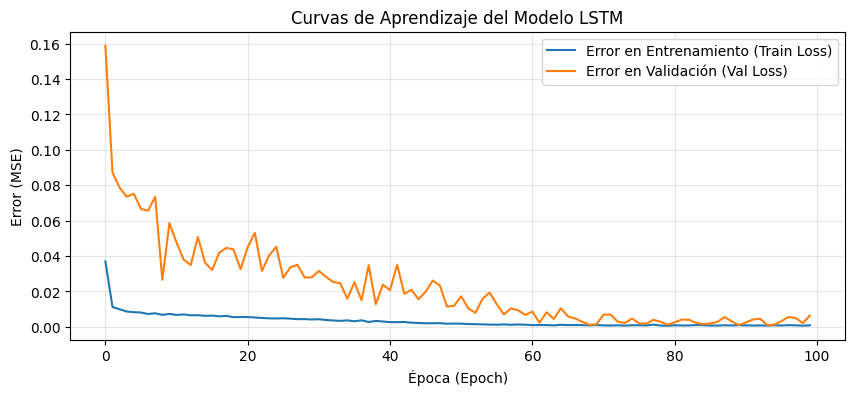


MÉTRICA 1 - RMSE (Error Cuadrático Medio en la escala real): 7.28
MÉTRICA 2 - Precisión Direccional: 76.92%


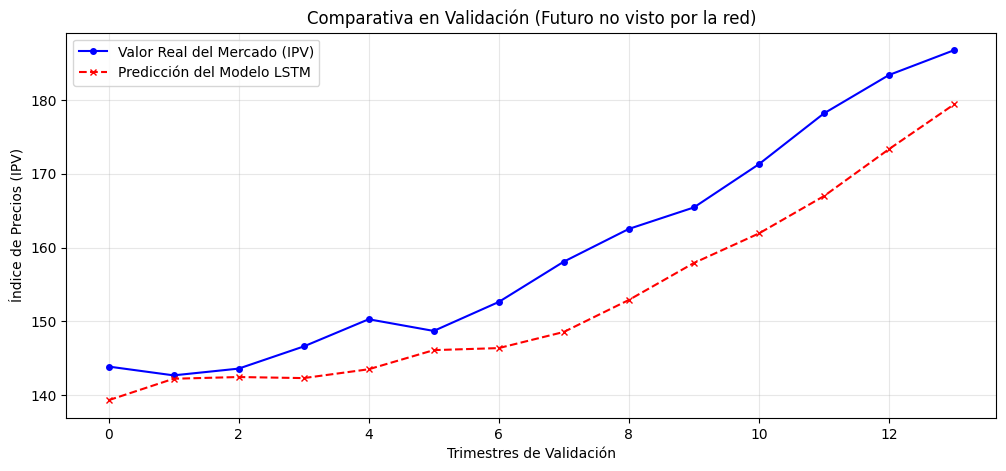

In [ ]:
from sklearn.metrics import mean_squared_error
import math

# 1. Hacer predicciones con el modelo ya entrenado
y_pred_escalado = modelo.predict(X_test)

# 2. Deshacer el escalamiento para volver a los valores reales del índice
y_pred = scaler.inverse_transform(y_pred_escalado)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---> GRÁFICA 1: CURVA DE APRENDIZAJE (LOSS)
plt.figure(figsize=(10, 4))
plt.plot(historia.history['loss'], label='Error en Entrenamiento (Train Loss)')
plt.plot(historia.history['val_loss'], label='Error en Validación (Val Loss)')
plt.title('Curvas de Aprendizaje del Modelo LSTM')
plt.xlabel('Época (Epoch)')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---> CÁLCULO DE MÉTRICAS

# RMSE (Root Mean Squared Error)
rmse = math.sqrt(mean_squared_error(y_test_real, y_pred))
print(f"\nMÉTRICA 1 - RMSE (Error Cuadrático Medio en la escala real): {rmse:.2f}")

# Precisión direccional (Directional Accuracy)
# Comparamos si la dirección (subir/bajar) de la predicción coincide con la realidad
direccion_real = np.sign(np.diff(y_test_real.flatten()))
direccion_pred = np.sign(np.diff(y_pred.flatten()))
aciertos = np.sum(direccion_real == direccion_pred)
precision_direccional = (aciertos / len(direccion_real)) * 100
print(f"MÉTRICA 2 - Precisión Direccional: {precision_direccional:.2f}%")

# ---> GRÁFICA 2: SERIE REAL VS PREDICHA
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, color='blue', label='Valor Real del Mercado (IPV)', marker='o', markersize=4)
plt.plot(y_pred, color='red', label='Predicción del Modelo LSTM', linestyle='--', marker='x', markersize=4)
plt.title('Comparativa en Validación (Futuro no visto por la red)')
plt.xlabel('Trimestres de Validación')
plt.ylabel('Índice de Precios (IPV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Fernando\Documents\proyecto\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando el modelo mejorado con 100 unidades LSTM... (Esto tomará unos segundos)
¡Entrenamiento finalizado!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step

--- RESULTADOS DEL MODELO CON 100 UNIDADES ---
Nueva Precisión Direccional: 76.92%


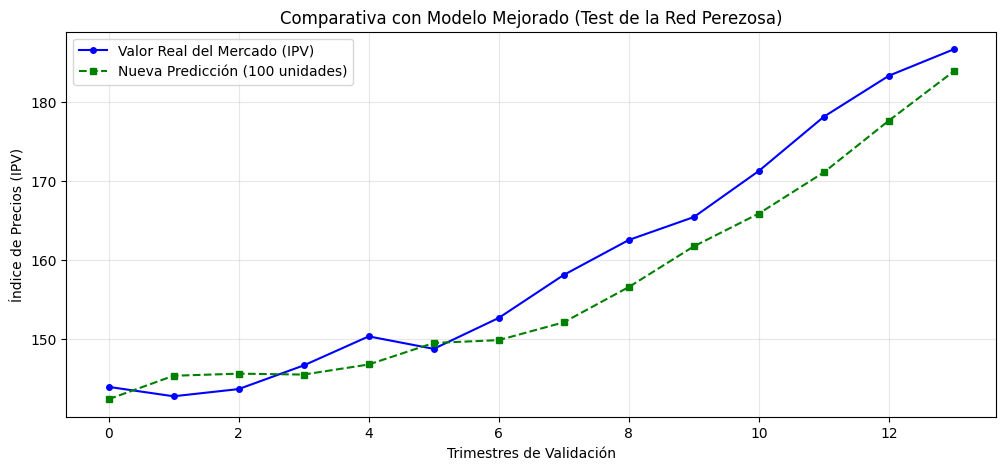

In [ ]:
# 1. Reconstruir el modelo con más memoria (100 unidades)
modelo_mejorado = Sequential()

# Aumentamos de 50 a 100 unidades en la capa LSTM
modelo_mejorado.add(LSTM(units=100, input_shape=(X_train.shape[1], 1))) 
modelo_mejorado.add(Dense(units=1))

# Compilamos usando RMSprop y MSE como antes
modelo_mejorado.compile(optimizer=RMSprop(), loss='mse')

print("Entrenando el modelo mejorado con 100 unidades LSTM... (Esto tomará unos segundos)")

# 2. Entrenar el nuevo modelo
historia_mejorada = modelo_mejorado.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=0 # Puesto a 0 para que no llene la pantalla de texto, trabajará en silencio
)
print("¡Entrenamiento finalizado!")

# 3. Hacer las nuevas predicciones
y_pred_escalado_mejorado = modelo_mejorado.predict(X_test)

# Deshacer el escalamiento
y_pred_mejorado = scaler.inverse_transform(y_pred_escalado_mejorado)

# 4. Recalcular la precisión direccional
direccion_real = np.sign(np.diff(y_test_real.flatten()))
direccion_pred_mejorada = np.sign(np.diff(y_pred_mejorado.flatten()))
aciertos_mejorados = np.sum(direccion_real == direccion_pred_mejorada)
precision_direccional_mejorada = (aciertos_mejorados / len(direccion_real)) * 100

print(f"\n--- RESULTADOS DEL MODELO CON 100 UNIDADES ---")
print(f"Nueva Precisión Direccional: {precision_direccional_mejorada:.2f}%")

# 5. Gráfica comparativa mejorada
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, color='blue', label='Valor Real del Mercado (IPV)', marker='o', markersize=4)
plt.plot(y_pred_mejorado, color='green', label='Nueva Predicción (100 unidades)', linestyle='--', marker='s', markersize=4)
plt.title('Comparativa con Modelo Mejorado (Test de la Red Perezosa)')
plt.xlabel('Trimestres de Validación')
plt.ylabel('Índice de Precios (IPV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()